# Google Cloud CMIP6 Public Data: Timeseries plot of total precipitation amount

**Derick Appiah Kubi** 

## Overview
This notebook uses query to load data from the Google Cloud CMIP6 catalog. It also goes on to;

1. Compute Monthly total Precipitation
2. Plots a timeseries for the mean of the total precipitation

---

## Prerequisites
This section was inspired by [CMIP6 Cookbook]( https://github.com/ProjectPythia/cmip6-cookbook) 


| Concepts | Importance | Notes |
| --- | --- | --- |
| [Intro to Xarray]| Necessary | |
| [Understanding of NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf) | Helpful | Familiarity with metadata structure |
| Total precipitation amount | Helpful | |

- **Time to learn**: 10 minutes

## Imports


In [1]:
import sys
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import zarr
import fsspec
import nc_time_axis
import cartopy.crs as ccrs
import cartopy.feature as cfeature

%matplotlib inline

#### Function for the weighted average

In [2]:
def tropical_mean(field):
    weights = np.cos(np.deg2rad(field.lat))
    return field.weighted(weights).mean(dim=['lat', 'lon'])

## Explore the collection

The catalog containing the data is saved as a CSV file, and it is loaded into Python using the Pandas library.

In [3]:
df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')
df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


### Selecting the variable and the projection
Here I sample the data to select the monthly precipitation flux for historical experiment and the future scenario (SSP585).

In [4]:
df_ssp585 = df.query("activity_id=='ScenarioMIP' & table_id == 'Amon' & variable_id == 'pr' & experiment_id == 'ssp585'")    # future scenario
df_his = df.query("activity_id=='CMIP' & table_id == 'Amon' & variable_id == 'pr' & experiment_id == 'historical'")        #historical
print(df_his)
print(df_ssp585)

       activity_id       institution_id      source_id experiment_id  \
994           CMIP            NOAA-GFDL      GFDL-ESM4    historical   
1773          CMIP            NOAA-GFDL      GFDL-ESM4    historical   
6263          CMIP            NOAA-GFDL       GFDL-CM4    historical   
22128         CMIP                 IPSL   IPSL-CM6A-LR    historical   
22279         CMIP                 IPSL   IPSL-CM6A-LR    historical   
...            ...                  ...            ...           ...   
523412        CMIP                  MRI     MRI-ESM2-0    historical   
523675        CMIP                KIOST      KIOST-ESM    historical   
523713        CMIP                 CMCC   CMCC-CM2-SR5    historical   
523727        CMIP                 CMCC   CMCC-CM2-SR5    historical   
523766        CMIP  EC-Earth-Consortium  EC-Earth3-Veg    historical   

       member_id table_id variable_id grid_label  \
994     r3i1p1f1     Amon          pr        gr1   
1773    r2i1p1f1     Amon      

### Selection of the model for the future scenario
Further sampling is done to select the model I want to use from MPI-M.

In [5]:
df_pr_MPI = df_ssp585.query('institution_id == "MPI-M"')
df_pr_MPI.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
221806,ScenarioMIP,MPI-M,MPI-ESM1-2-LR,ssp585,r7i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-...,NaN,20190710
221965,ScenarioMIP,MPI-M,MPI-ESM1-2-LR,ssp585,r6i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-...,NaN,20190710
224170,ScenarioMIP,MPI-M,MPI-ESM1-2-LR,ssp585,r9i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-...,NaN,20190710
224529,ScenarioMIP,MPI-M,MPI-ESM1-2-LR,ssp585,r8i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-...,NaN,20190710
225410,ScenarioMIP,MPI-M,MPI-ESM1-2-LR,ssp585,r10i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-...,NaN,20190710


### Selection of the model for the historical experiment


In [6]:
df_pr_MPIhis = df_his.query('institution_id == "MPI-M"')
df_pr_MPIhis.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
222407,CMIP,MPI-M,MPI-ESM1-2-LR,historical,r1i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/hist...,NaN,20190710
223087,CMIP,MPI-M,MPI-ESM1-2-LR,historical,r10i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/hist...,NaN,20190710
223155,CMIP,MPI-M,MPI-ESM1-2-HR,historical,r3i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-HR/hist...,NaN,20190710
223391,CMIP,MPI-M,MPI-ESM1-2-HR,historical,r10i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-HR/hist...,NaN,20190710
232875,CMIP,MPI-M,MPI-ESM1-2-LR,historical,r5i1p1f1,Amon,pr,gn,gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/hist...,NaN,20190710


## Loading of the data
The data is loaded using fsspec, zarr and xarray from a single store.

In [7]:
# get the path to a specific zarr store (the first one from the dataframe above)
zstore = df_pr_MPI.zstore.values[7]
print(zstore)
zstorehis = df_pr_MPIhis.zstore.values[0]
print(zstorehis)

# create a mutable-mapping-style interface to the store
mapper = fsspec.get_mapper(zstore)
mapperhis = fsspec.get_mapper(zstorehis)

# open it using xarray and zarr
ds_ssp585 = xr.open_zarr(mapper, consolidated=True)
ds_his = xr.open_zarr(mapperhis, consolidated=True)

gs://cmip6/CMIP6/ScenarioMIP/MPI-M/MPI-ESM1-2-LR/ssp585/r1i1p1f1/Amon/pr/gn/v20190710/
gs://cmip6/CMIP6/CMIP/MPI-M/MPI-ESM1-2-LR/historical/r1i1p1f1/Amon/pr/gn/v20190710/


### Calculating the total precipitation amount
In this section, the variable precipitation flux is selected from the data, the total precipitation amount is calculated and the unit is also changed

In [8]:
ds_pr_ssp585 = ds_ssp585['pr']    #selection of the variable precipitation flux
days = ds_pr_ssp585['time'].dt.days_in_month       #getting the right number of days from the data
ds_pr_ssp585 = ds_ssp585['pr'] * days * 86400         #calculating the total precipitation amount
ds_pr_ssp585.attrs['units'] = 'mm'                    # changing the unit from kg/m2/s to mm
ds_pr_ssp585.attrs['Long name'] = 'Total precipitation amount'          #redefining the long name
ds_pr_ssp585

<xarray.DataArray (time: 1032, lat: 96, lon: 192)> Size: 152MB
dask.array<mul, shape=(1032, 96, 192), dtype=float64, chunksize=(516, 96, 192), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 8kB 2015-01-16T12:00:00 ... 2100-12-16T12:...
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Attributes:
    units:      mm
    Long name:  Total precipitation amount

The same process that was done for the future scenario is done for the historical experiment

In [9]:
ds_pr_his = ds_his['pr']
days = ds_pr_his['time'].dt.days_in_month
ds_pr_his = ds_his['pr']* days * 86400
ds_pr_his.attrs['units'] = 'mm/day'
ds_pr_his.attrs['Long name'] = 'Total precipitation amount'
ds_pr_his

<xarray.DataArray (time: 1980, lat: 96, lon: 192)> Size: 292MB
dask.array<mul, shape=(1980, 96, 192), dtype=float64, chunksize=(904, 96, 192), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 16kB 1850-01-16T12:00:00 ... 2014-12-16T12...
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
Attributes:
    units:      mm/day
    Long name:  Total precipitation amount

### 

### Selection of the study area and time

In [10]:
ds_sa_ssp585 = ds_pr_ssp585.sel(lon=slice(-120 + 360, -20 + 360), lat=slice(-15, 25))  #Selecting the study area

years = ds_sa_ssp585['time'].dt.year
ds_2080_2100 = ds_sa_ssp585.where((years >= 2080) & (years <= 2100), drop=True)  # specifying the specific into the future I want to look at

mean_2080_2100 = ds_2080_2100.mean(dim='time')    # finding the mean at the time dimension



ds_sa_his = ds_pr_his.sel(lon=slice(-120 + 360, -20 + 360), lat=slice(-15, 25))    #study area selection

years = ds_sa_his['time'].dt.year
ds_1986_2005 = ds_sa_his.where((years >= 1986) & (years <= 2005), drop=True)   #subsetting the time

mean_1986_2005 = ds_1986_2005.mean(dim='time')  # time mean

### Calculating the weighted mean

In [11]:
pr_timeseries_his = tropical_mean(ds_1986_2005)
pr_timeseries_his

<xarray.DataArray (time: 240)> Size: 2kB
dask.array<truediv, shape=(240,), dtype=float64, chunksize=(240,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2kB 1986-01-16T12:00:00 ... 2005-12-16T12:...

### Loading the Historical Timeseries

In [12]:
pr_timeseries_his.load()

<xarray.DataArray (time: 240)> Size: 2kB
array([ 91.29837019,  75.41530242,  94.63308261, 123.40988399,
       119.91435112, 105.72123337, 105.37482381, 119.67734313,
       129.58997928, 117.88164659, 115.36447156, 112.66201592,
        93.68717022,  82.80133124,  95.55847316, 117.10963197,
        98.50177402, 118.66498674,  94.40334781, 121.98597422,
       113.31931081, 119.10246464, 119.19768249, 100.88585253,
        91.30503501,  85.81373412,  97.19414536,  95.0678766 ,
        92.10577572, 102.59737029,  87.31583203,  93.95307936,
       103.24078377, 122.54738351,  92.22129746,  96.97408041,
        73.33183525,  80.67467371,  95.48098648, 103.69638731,
       109.35949899,  97.72694782,  85.92843082,  95.42704134,
       117.63611865, 118.62344416, 106.61760546, 106.33191146,
        84.53628325,  69.46027306,  91.36415225,  95.79689018,
        84.86935457, 105.91129092,  87.2222553 , 100.63576688,
       108.40677134, 108.86428597,  96.97757593,  89.29799581,
        82.73101862,  89.01545498, 101.78026095,  98.98341883,
        94.98004215, 103.06042284,  90.09193341, 115.05279141,
        97.63092003, 114.52311117, 122.98172679,  90.56351138,
        89.36415997,  75.23947799,  92.09336733,  89.28952778,
       111.38913296, 111.6913849 ,  97.80764053,  96.22543078,
...
       114.79790828, 113.74854313, 113.8520234 ,  97.15026444,
       116.34494219, 121.63495224, 125.21542545, 109.14489753,
        82.64997198,  81.47402008, 100.57458487, 117.04530636,
       118.99610246,  99.76975002, 102.95792536, 113.94991285,
       122.79340048, 120.65808741, 118.23452667, 101.68346167,
        82.65080803,  76.98070369, 104.06886185,  94.95746664,
       102.37631684,  97.18428289,  92.43236173,  94.6836444 ,
       109.04081251, 121.40023325, 110.27763453,  98.75810892,
        93.69205042,  75.589517  ,  95.20169991,  88.83804055,
        93.62215734,  92.13746265,  89.67887229,  88.79684099,
       107.64181647, 114.49490925,  95.38004288,  83.3463085 ,
        74.39254332,  76.39437023, 102.17125164,  81.66870868,
        99.26184608,  94.29864661, 104.82436006, 104.83674382,
       107.5118984 , 122.33670704,  99.27468516,  91.00955378,
        80.56255222,  75.22741236,  88.43710201, 101.88555741,
       101.1214474 , 122.82953494, 100.56740241, 103.51851625,
       135.97274528, 120.09594294, 111.49759423,  96.96764152,
        88.73936513,  75.31104923,  93.3005614 ,  96.25229585,
       103.67287972,  95.97279539,  92.79367721, 115.96447667,
       108.87662509, 119.52373185, 104.24869268, 104.84538879])
Coordinates:
  * time     (time) datetime64[ns] 2kB 1986-01-16T12:00:00 ... 2005-12-16T12:...

### Plotting of the Histotrical Timeseries

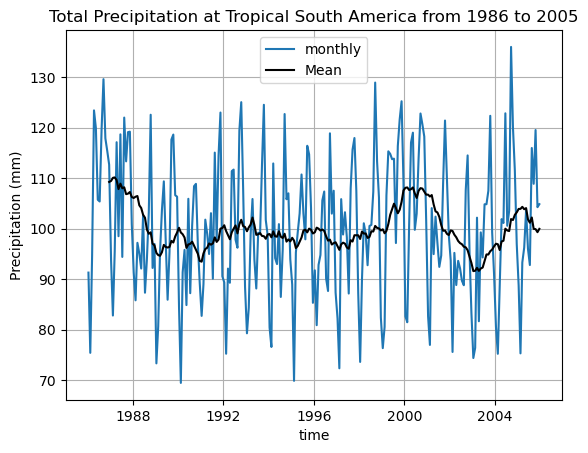

In [13]:
title = 'Total Precipitation at Tropical South America from 1986 to 2005'
pr_timeseries_his.plot(label='monthly')
pr_timeseries_his.rolling(time=12).mean().plot(label='Mean', color='k')
plt.legend()
plt.grid()
plt.ylabel('Precipitation (mm)')
plt.title(f'{title}')
plt.show()

### Calculating the weighted mean

In [14]:
pr_timeseries = tropical_mean(ds_2080_2100)
pr_timeseries

<xarray.DataArray (time: 252)> Size: 2kB
dask.array<truediv, shape=(252,), dtype=float64, chunksize=(252,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 2kB 2080-01-16T12:00:00 ... 2100-12-16T12:...

### Loading the Future scenario (SSP585) Timeseries

In [15]:
pr_timeseries.load()

<xarray.DataArray (time: 252)> Size: 2kB
array([ 74.23178148,  68.20805995,  99.44440913,  92.32332124,
        95.38712445, 100.89948906,  74.93671176,  88.6164199 ,
        86.47636221, 126.74287095, 105.9619447 ,  88.54456786,
        76.9855468 ,  70.54242025,  87.61080027,  86.72920223,
        96.55033218, 114.25779452,  79.48376649,  96.63098917,
        83.73374351, 117.78848244, 106.93107798,  88.78689712,
        79.38974516,  62.98416084,  89.24344161, 100.29639648,
        89.86415832, 100.24538878,  88.8379302 ,  87.67637439,
        98.15616737, 101.17936552, 111.21865276, 109.34324224,
        90.10023052,  64.79794682,  86.56694119,  98.46557764,
        91.72149318,  93.91519964,  79.97933956,  78.40431418,
        86.47232187, 116.53263768, 109.54582545,  98.82165961,
        81.26409298,  74.70409372,  86.81017577, 109.85250736,
        92.49681561,  88.08238974,  82.22018694,  82.47665249,
        98.81014868, 108.31663028, 110.4535572 ,  88.09857945,
        76.3206788 ,  66.91318305,  95.34553048,  86.96649069,
       103.87162623,  94.27705123,  73.35151255,  77.60884851,
        82.40872298, 118.16116585, 112.18427583,  90.27033502,
        81.53332665,  69.52310459,  99.93003312, 105.87206446,
       114.73034575,  99.3000408 ,  92.65174805,  87.75955368,
...
       100.88284084,  82.36089371,  69.00418686,  75.78298144,
        80.33625682, 116.12788823, 102.86110696,  95.24390211,
        84.91610033,  64.52906187,  93.59556418,  83.91144768,
       106.58592456,  90.69171269,  92.17096195,  76.71772836,
        99.13358794, 118.2256778 , 104.36384524,  88.60752303,
        84.3128018 ,  73.6880127 ,  95.50396483, 103.70873994,
        89.84558658,  88.59775735,  78.08437665,  84.7495475 ,
        90.46097895, 112.76268603, 109.06221064,  91.08970733,
        74.39325114,  67.19804786,  93.50903515, 102.66876826,
       106.68387187, 103.71332572,  65.62195737,  77.20542121,
        96.44440387, 112.37313167, 111.3566976 , 100.98513824,
        79.4062688 ,  72.40963544,  92.17261615, 108.08104666,
        91.03329791, 113.62412639,  83.28642769,  91.00052684,
        83.4345083 , 101.16209414, 117.70085223,  91.59681308,
        81.89586052,  74.34595031,  90.74571853,  98.16268337,
        97.01558096,  94.24870926, 101.30800151, 101.02938939,
        93.26505037, 132.54770395,  99.09088946, 100.31366317,
        88.78274556,  70.53934724,  88.94088854, 107.23375443,
       115.91401968, 102.3468274 ,  82.42813804,  82.78887657,
        94.90633355,  99.8060162 ,  93.89546314,  94.61904597])
Coordinates:
  * time     (time) datetime64[ns] 2kB 2080-01-16T12:00:00 ... 2100-12-16T12:...

### Plotting of the Future Scenario (SSP585) Timeseries

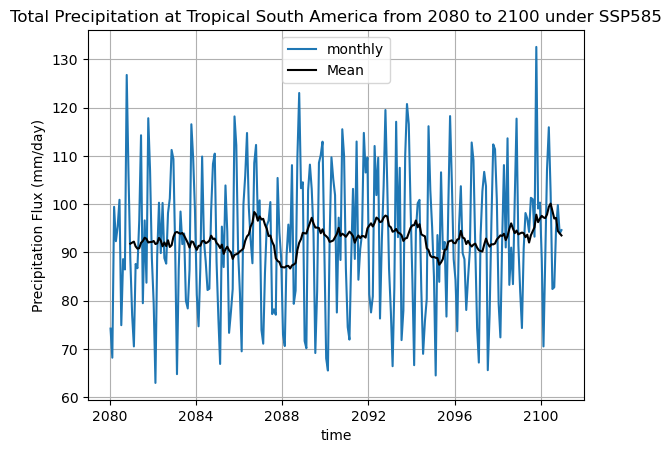

In [16]:
title = 'Total Precipitation at Tropical South America from 2080 to 2100 under SSP585' 
pr_timeseries.plot(label='monthly')
pr_timeseries.rolling(time=12).mean().plot(label='Mean', color='k')
plt.legend()
plt.grid()
plt.ylabel('Precipitation Flux (mm/day)')
plt.title(f'{title}')
plt.show()

## Summary
In this notebook, I opened a MPI-ESM1-2-LR dataset with fsspec and zarr. I calculated and made a timeseries of historical and future scenario (ssp585) total precipitation amount.

### What's next?
I will open and a MPI-ESM1-2-LR dataset with fsspec and zarr and make a spatial plot of historical and future scenario (ssp585) total precipitation amount.

## Resources and references
- [Original notebook in the Pangeo Gallery](http://gallery.pangeo.io/repos/pangeo-gallery/cmip6/ECS_Gregory_method.html) by Henri Drake and [Ryan Abernathey](https://ocean-transport.github.io/)
   
 
